<a href="https://colab.research.google.com/github/ava-ly/ds-projects/blob/main/Final_project_Crime_in_LA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crime Trend Analysis in Los Angeles (2020-2023)

<img src='https://raw.githubusercontent.com/ava-ly/ds-projects/main/crime-in-LA/crime-banner.png'>


## Dataset Overview

The dataset provides a detailed account of crime incidents reported in the City of Los Angeles from January 2020 to August 2024. The data is compiled from the Los Angeles Police Department (LAPD) and includes various features like the type of crime, date and time of occurrence, location, and demographic information of victims. In order to provide an analysis with objectivity and consistency, only data `from January 2020 to December 2023` will be selected. Additionally, this dataset is invaluable for researchers, data scientists, and analysts who are interested in studying crime trends, identifying patterns, and developing predictive models to enhance public safety.

### Data Features:






- `DR_NO`: Unique identifier for each crime report.
- `Date Rptd`: Date the crime was reported.
- `DATE OCC`: Date and time when the crime occurred.
- `TIME OCC`: Time when the crime occurred.
- `AREA`: Area code where the crime took place.
- `AREA NAME`: Name of the area or neighborhood where the crime took place.
- `Rpt Dist No`: Reporting district number, a smaller unit within the area.
- `Part 1-2`: Classification of the crime as either Part 1 (serious) or Part 2 (less serious).
- `Crm Cd`:	Crime code representing the specific type of crime.
- `Crm Cd Desc`: Description of the type of crime (e.g., BURGLARY, THEFT).
- `Mocodes`: Modus operandi codes detailing how the crime was committed.
- `Vict Age`: Age of the victim.
- `Vict Sex`: Gender of the victim (M = Male, F = Female, X = Non-binary).
- `Vict Descent`: Ethnic descent of the victim (O = Other, W = White, B = Black, H = Hispanic, etc.).
- `Premis Cd`: Code representing the type of premise where the crime occurred.
- `Premis Desc`: Description of the premise where the crime occurred (e.g., STREET, CLOTHING STORE).
- `Weapon Used Cd`:	Code for the weapon used in the crime.
- `Weapon Desc`: Description of the weapon used in the crime (e.g., FIREARM, KNIFE).
- `Status`: Current status of the investigation (e.g., AA = Adult Arrest, IC = Investigation Continued).
- `Status Desc`: Detailed description of the investigation status.
- `Crm Cd 1`: Primary crime code associated with the incident.
- `Crm Cd 2`: Secondary crime code, if applicable.
- `Crm Cd 3`: Tertiary crime code, if applicable.
- `Crm Cd 4`: Quaternary crime code, if applicable.
- `LOCATION`: Address or location where the crime occurred.
- `Cross Street`: Nearest cross street to the location of the crime.
- `LAT`: Latitude coordinate of the crime location.
- `LON`: Longitude coordinate of the crime location.


## Big Question: How to enhance public safety in LA?


## Project Plan

1. Data Preprocessing:
    - Load and inspect data.
    - Column selection.
    - Handling missing values.
    - Standardize data for convenience.

2. Exploratory Data Analysis (EDA)
    - How do crime rates vary by year, month, day of week, or hour of day?
    - Are certain crimes more frequent at night vs. day?
    - Has crime increased or decreased from 2020 to 2023?
    - Are there seasonal spikes in certain crimes?
    - Geospatial analysis for crime hotspots.
    - Which areas have the highest crime rates?
    - Are certain crimes concentrated in specific neighborhoods?
    - Are certain demographics more frequently victimized?
    - Does weapon usage vary by crime type?

3. Feature Engineering
    - Time-based (hour, day, month, weekend vs. weekday).
    - Location-based (neighborhood clusters).
    - Crime category encoding for predictive modeling.

4. Machine Learning Models
    - Classification Task: Predict crime category using Random Forest.
    

5. Visualization & Reporting
    - Key findings summarized in a report with Google Slides



---



# 1. Data Preprocessing


## 1.1 Load and Inspect Data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = 'https://media.githubusercontent.com/media/ava-ly/ds-projects/main/crime-in-LA/Crime_Data_from_2020_to_Present.csv'

df = pd.read_csv(url)
print("File loaded successfully!")
print(f"\nShape of the DataFrame: {df.shape}")

File loaded successfully!

Shape of the DataFrame: (966951, 28)


In [ ]:
df.sample(5).T

,730514,52231,80591,578129,649446
DR_NO,230504487,210704391,200612203,221006033,232104107
Date Rptd,01/12/2023 12:00:00 AM,01/12/2021 12:00:00 AM,07/05/2020 12:00:00 AM,02/22/2022 12:00:00 AM,01/04/2023 12:00:00 AM
DATE OCC,01/11/2023 12:00:00 AM,12/28/2020 12:00:00 AM,07/04/2020 12:00:00 AM,02/22/2022 12:00:00 AM,01/03/2023 12:00:00 AM
TIME OCC,800,1,230,1840,700
AREA,5,7,6,10,21
AREA NAME,Harbor,Wilshire,Hollywood,West Valley,Topanga
Rpt Dist No,515,724,632,1023,2136
Part 1-2,2,2,1,1,2
Crm Cd,813,354,330,330,354
Crm Cd Desc,CHILD ANNOYING (17YRS & UNDER),THEFT OF IDENTITY,BURGLARY FROM VEHICLE,BURGLARY FROM VEHICLE,THEFT OF IDENTITY


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966951 entries, 0 to 966950
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           966951 non-null  int64  
 1   Date Rptd       966951 non-null  object 
 2   DATE OCC        966951 non-null  object 
 3   TIME OCC        966951 non-null  int64  
 4   AREA            966951 non-null  int64  
 5   AREA NAME       966951 non-null  object 
 6   Rpt Dist No     966951 non-null  int64  
 7   Part 1-2        966951 non-null  int64  
 8   Crm Cd          966951 non-null  int64  
 9   Crm Cd Desc     966951 non-null  object 
 10  Mocodes         826575 non-null  object 
 11  Vict Age        966951 non-null  int64  
 12  Vict Sex        833245 non-null  object 
 13  Vict Descent    833235 non-null  object 
 14  Premis Cd       966937 non-null  float64
 15  Premis Desc     966375 non-null  object 
 16  Weapon Used Cd  325476 non-null  float64
 17  Weapon Des

In [ ]:
df.isna().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Rpt Dist No,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## 1.2 Column Selection

In [ ]:
# Remove unwanted columns
columns_to_drop = [
    'Mocodes', 'Cross Street', 'Crm Cd 1', 'Crm Cd 2',
    'Crm Cd 3', 'Crm Cd 4','Weapon Used Cd', 'Premis Cd'
]
df = df.drop(columns=columns_to_drop, errors='ignore')

In [ ]:
df.sample(5).T

,906069,761307,263811,108826,610868
DR_NO,241009902,230616811,210611584,200412663,221416896
Date Rptd,07/13/2024 12:00:00 AM,10/21/2023 12:00:00 AM,06/21/2021 12:00:00 AM,09/11/2020 12:00:00 AM,09/26/2022 12:00:00 AM
DATE OCC,06/20/2024 12:00:00 AM,10/20/2023 12:00:00 AM,06/21/2021 12:00:00 AM,09/11/2020 12:00:00 AM,09/24/2022 12:00:00 AM
TIME OCC,1800,2130,200,1900,805
AREA,10,6,6,4,14
AREA NAME,West Valley,Hollywood,Hollywood,Hollenbeck,Pacific
Rpt Dist No,1008,659,636,499,1494
Part 1-2,1,1,1,1,1
Crm Cd,420,330,230,510,341
Crm Cd Desc,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),BURGLARY FROM VEHICLE,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",VEHICLE - STOLEN,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI..."


## 1.3 Handle Missing Values

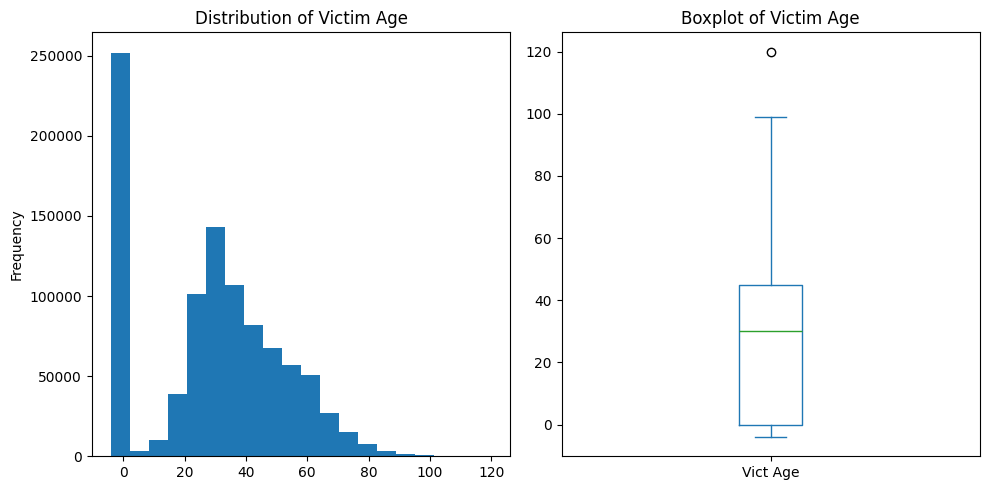

Mean Age:, 29.3
Median Age:, 30.0
Age Range:, -4 to 120


In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['Vict Age'].plot(kind='hist', bins=20, title='Distribution of Victim Age')
plt.subplot(1, 2, 2)
df['Vict Age'].plot(kind='box', title='Boxplot of Victim Age')
plt.tight_layout()
plt.show()

print(f"Mean Age:, {df['Vict Age'].mean():.1f}")
print(f"Median Age:, {df['Vict Age'].median()}")
print(f"Age Range:, {df['Vict Age'].min()} to {df['Vict Age'].max()}")

Observation: error in data entry made the strange age appear in the dataset. Let's set the age range from 5 to 100 years old.

In [ ]:
df = df[(df['Vict Age'] >= 5) & (df['Vict Age'] <= 100)].copy()
print(f"Cleaned Age Range: {df['Vict Age'].min()} to {df['Vict Age'].max()}")
print(f"Cleaned Age Mean: {df['Vict Age'].mean():.1f}, Median: {df['Vict Age'].median()}")

Cleaned Age Range: 5 to 99
Cleaned Age Mean: 39.6, Median: 37.0


In [ ]:
df[['Vict Sex', 'Vict Descent', 'Weapon Desc', 'Premis Desc']] = \
df[['Vict Sex', 'Vict Descent', 'Weapon Desc', 'Premis Desc']].fillna('Unknown')
df.sample(5).T

,693503,89832,502680,653216,269889
DR_NO,231605969,201208086,221016473,231410083,211108545
Date Rptd,03/04/2023 12:00:00 AM,02/28/2020 12:00:00 AM,11/14/2022 12:00:00 AM,05/09/2023 12:00:00 AM,05/13/2021 12:00:00 AM
DATE OCC,02/27/2023 12:00:00 AM,02/28/2020 12:00:00 AM,11/12/2022 12:00:00 AM,03/23/2023 12:00:00 AM,05/09/2021 12:00:00 AM
TIME OCC,2128,2105,2030,1537,900
AREA,16,12,10,14,11
AREA NAME,Foothill,77th Street,West Valley,Pacific,Northeast
Rpt Dist No,1638,1207,1012,1416,1183
Part 1-2,2,1,2,2,1
Crm Cd,901,350,740,354,440
Crm Cd Desc,VIOLATION OF RESTRAINING ORDER,"THEFT, PERSON","VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",THEFT OF IDENTITY,THEFT PLAIN - PETTY ($950 & UNDER)


In [ ]:
df.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Rpt Dist No,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0


In [ ]:
print("Unique values after cleaning:")
print(f"Vict Sex: {df['Vict Sex'].unique()}")
print(f"Vict Descent: {df['Vict Descent'].unique()}")
print(f"Total number of crime types: {df['Crm Cd Desc'].nunique()}")

Unique values after cleaning:
Vict Sex: ['M' 'X' 'F' 'H' 'Unknown']
Vict Descent: ['O' 'X' 'H' 'B' 'W' 'A' 'K' 'C' 'J' 'F' 'I' 'V' 'S' 'P' 'Z' 'Unknown' 'G'
 'U' 'D' 'L' '-']
Total number of crime types: 137


## 1.4 Stardardize Data

In [ ]:
# Standard Sex Codes: M/F/X
df['Vict Sex'] = df['Vict Sex'].replace({
    'M': 'Male',
    'F': 'Female',
    'H': 'Other',
    'Unknown': 'Other',
    'X': 'Other'
}).str.upper()
print(f"Unique values after cleaning: {df['Vict Sex'].unique()}")

Unique values after cleaning: ['MALE' 'OTHER' 'FEMALE']


In [ ]:
# Standard Descent (Race/Ethnicity) Codes:
# B: Black, W: White, H: Hispanic, A: Asian, O: Other, X: Unknown
df['Vict Descent'] = df['Vict Descent'].replace({
    'B': 'Black',
    'W': 'White',
    'H': 'Hispanic',
    'A': 'Asian',
    'O': 'Other',
    'X': 'Unknown',
    '-': 'Unknown',  # Missing → Unknown
    'K': 'Asian',    # Korean → Asian
    'C': 'Asian',    # Chinese → Asian
    'J': 'Asian',    # Japanese → Asian
    'F': 'Asian',    # Filipino → Asian
    'V': 'Asian',    # Vietnamese → Asian
    'I': 'Other',    # American Indian → Other
    'S': 'Other',    # Samoan → Other
    'P': 'Other',    # Pacific Islander → Other
    'Z': 'Asian',    # Asian Indian → Asian
    'G': 'Other',    # Guamanian → Other
    'U': 'Unknown',  # Unknown
    'D': 'Asian',    # Cambodian → Asian
    'L': 'Asian'     # Laotian → Asian
})
print(f"Unique values after cleaning: {df['Vict Descent'].unique()}")

Unique values after cleaning: ['Other' 'Unknown' 'Hispanic' 'Black' 'White' 'Asian']


In [ ]:
# Custom crime categorization: 137 (10 groups)
crime_category_mapping = {
    # 1. Vehicle-Related Crimes: 12
    'VEHICLE_CRIMES': [
        'BURGLARY FROM VEHICLE', 'BURGLARY FROM VEHICLE, ATTEMPTED',
        'BIKE - STOLEN', 'BIKE - ATTEMPTED STOLEN',
        'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)',
        'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)',
        'THEFT FROM MOTOR VEHICLE - ATTEMPT',
        'VEHICLE - STOLEN', 'VEHICLE - ATTEMPT STOLEN',
        'VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)',
        'DRIVING WITHOUT OWNER CONSENT (DWOC)',
        'THROWING OBJECT AT MOVING VEHICLE',
    ],

    # 2. Theft & Burglary: 23 (Non-Vehicle)
    'THEFT_BURGLARY': [
        'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)',
        'SHOPLIFTING - PETTY THEFT ($950 & UNDER)', 'SHOPLIFTING - ATTEMPT',
        'THEFT PLAIN - PETTY ($950 & UNDER)', 'THEFT PLAIN - ATTEMPT',
        'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD',
        'BURGLARY', 'BURGLARY, ATTEMPTED',
        'PICKPOCKET', 'PICKPOCKET, ATTEMPT',
        'PURSE SNATCHING', 'PURSE SNATCHING - ATTEMPT',
        'THEFT, PERSON', 'THEFT FROM PERSON - ATTEMPT',
        'DISHONEST EMPLOYEE - GRAND THEFT', 'DISHONEST EMPLOYEE - PETTY THEFT',
        'DISHONEST EMPLOYEE ATTEMPTED THEFT',
        'TILL TAP - PETTY ($950 & UNDER)',
        'TILL TAP - GRAND THEFT ($950.01 & OVER)',
        'THEFT, COIN MACHINE - PETTY ($950 & UNDER)',
        'THEFT, COIN MACHINE - GRAND ($950.01 & OVER)',
        'THEFT, COIN MACHINE - ATTEMPT',
        'DRUNK ROLL',
    ],

    # 3. Violent Crimes: 22 (Assault, Homicide, Threats, Kidnapping etc.)
    'VIOLENT_CRIMES': [
        'BATTERY - SIMPLE ASSAULT', 'INTIMATE PARTNER - SIMPLE ASSAULT',
        'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT',
        'INTIMATE PARTNER - AGGRAVATED ASSAULT',
        'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER',
        'BATTERY POLICE (SIMPLE)', 'BATTERY ON A FIREFIGHTER',
        'OTHER ASSAULT', 'ROBBERY', 'ATTEMPTED ROBBERY',
        'CRIMINAL HOMICIDE', 'MANSLAUGHTER, NEGLIGENT',
        'CRIMINAL THREATS - NO WEAPON DISPLAYED',
        'THREATENING PHONE CALLS/LETTERS', 'EXTORTION',
        'KIDNAPPING', 'KIDNAPPING - GRAND ATTEMPT',
        'FALSE IMPRISONMENT', 'STALKING',
        'LYNCHING', 'LYNCHING - ATTEMPTED',
        'BATTERY WITH SEXUAL CONTACT'
    ],

    # 4. Sex Offenses: 17 (Incl. against minors if primary nature is sexual)
    'SEX_OFFENSES': [
        'SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH',
        'SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ',
        'LETTERS, LEWD  -  TELEPHONE CALLS, LEWD', 'LEWD CONDUCT',
        'ORAL COPULATION', 'RAPE, FORCIBLE', 'RAPE, ATTEMPTED',
        'SEXUAL PENETRATION W/FOREIGN OBJECT',
        'LEWD/LASCIVIOUS ACTS WITH CHILD', # Child victim, primarily sexual act
        'INDECENT EXPOSURE', 'PEEPING TOM',
        'CHILD PORNOGRAPHY', # Child victim, primarily sexual content crime
        'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)',
        'BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM',
        'PIMPING', 'PANDERING', # Exploitation related to sex acts
        'HUMAN TRAFFICKING - COMMERCIAL SEX ACTS'
    ],

    # 5. Crimes Against Children: 9 (Non-Sexual Abuse, Neglect, Endangerment)
    'CRIMES_AGAINST_CHILDREN': [
        'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)',
        'CHILD ANNOYING (17YRS & UNDER)',
        'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT',
        'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT',
        'CHILD STEALING', 'CHILD NEGLECT (SEE 300 W.I.C.)',
        'CHILD ABANDONMENT',
        'CONTRIBUTING', # likely Contrib. to Delinquency of Minor
        'DRUGS, TO A MINOR',
    ],

    # 6. Fraud & financial crimes: 19
    'FRAUD_FINANCIAL': [
        'THEFT OF IDENTITY',
        'BUNCO, GRAND THEFT', 'BUNCO, PETTY THEFT', 'BUNCO, ATTEMPT',
        'EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)',
        'EMBEZZLEMENT, PETTY THEFT ($950 & UNDER)',
        'CREDIT CARDS, FRAUD USE ($950.01 & OVER)',
        'CREDIT CARDS, FRAUD USE ($950 & UNDER',
        'DOCUMENT FORGERY / STOLEN FELONY',
        'DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER',
        'DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01',
        'DOCUMENT WORTHLESS ($200.01 & OVER)',
        'DOCUMENT WORTHLESS ($200 & UNDER)',
        'COUNTERFEIT',
        'GRAND THEFT / INSURANCE FRAUD',
        'PETTY THEFT - AUTO REPAIR', # assuming fraud
        'GRAND THEFT / AUTO REPAIR', # assuming fraud
        'UNAUTHORIZED COMPUTER ACCESS',
        'BRIBERY'
    ],

    # 7. Vandalism & Property Damage: 4
    'VANDALISM_PROPERTY_DAMAGE': [
         'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)',
         'VANDALISM - MISDEAMEANOR ($399 OR UNDER)',
         'ARSON',
         'TELEPHONE PROPERTY - DAMAGE',
    ],

    # 8. Public disorder: 10 (affects quality of life)
    'PUBLIC_DISORDER': [
        'TRESPASSING',
        'DISTURBING THE PEACE',
        'FALSE POLICE REPORT',
        'ILLEGAL DUMPING',
        'PROWLER',
        'RECKLESS DRIVING',
        'RESISTING ARREST',
        'DISRUPT SCHOOL',
        'INCITING A RIOT',
        'FAILURE TO YIELD'
    ],

    # 9. Public safety crimes: 16 (Weapons, Orders, Trafficking, High Risk)
    'PUBLIC_SAFETY': [
        'BRANDISH WEAPON',
        'WEAPONS POSSESSION/BOMBING',
        'DISCHARGE FIREARMS/SHOTS FIRED',
        'SHOTS FIRED AT INHABITED DWELLING',
        'SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT',
        'REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)',
        'VIOLATION OF RESTRAINING ORDER',
        'VIOLATION OF TEMPORARY RESTRAINING ORDER',
        'VIOLATION OF COURT ORDER', 'CONTEMPT OF COURT',
        'FIREARMS RESTRAINING ORDER (FIREARMS RO)',
        'FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)',
        'SEX OFFENDER REGISTRANT OUT OF COMPLIANCE',
        'BOMB SCARE', 'HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE',
        'TRAIN WRECKING'
    ],

    # 10. Other crimes: 5 (Miscellaneous, Rare)
    'OTHER_CRIMES': [
        'OTHER MISCELLANEOUS CRIME',
        'CRUELTY TO ANIMALS',
        'BIGAMY',
        'BLOCKING DOOR INDUCTION CENTER',
        'CONSPIRACY'
    ]
}

def crime_mapping(description):
    description = description.upper()
    for category, crimes in crime_category_mapping.items():
        if any(crime in description for crime in crimes):
            return category
    return 'OTHER_CRIMES'

df['Crime Category'] = df['Crm Cd Desc'].apply(crime_mapping)

In [ ]:
df['Crime Category'].value_counts()

,count
Crime Category,
VIOLENT_CRIMES,247043
THEFT_BURGLARY,130106
VEHICLE_CRIMES,121571
FRAUD_FINANCIAL,70526
VANDALISM_PROPERTY_DAMAGE,65332
PUBLIC_SAFETY,38203
SEX_OFFENSES,18576
PUBLIC_DISORDER,10794
CRIMES_AGAINST_CHILDREN,7256


In [ ]:
df.sample(5).T

,707905,337657,300032,613143,823212
DR_NO,231200650,211410471,211224356,221014326,231916179
Date Rptd,06/10/2023 12:00:00 AM,04/22/2021 12:00:00 AM,12/01/2021 12:00:00 AM,09/22/2022 12:00:00 AM,11/04/2023 12:00:00 AM
DATE OCC,06/10/2023 12:00:00 AM,04/22/2021 12:00:00 AM,12/01/2021 12:00:00 AM,09/20/2022 12:00:00 AM,11/03/2023 12:00:00 AM
TIME OCC,255,1250,1100,1600,1600
AREA,12,14,12,10,19
AREA NAME,77th Street,Pacific,77th Street,West Valley,Mission
Rpt Dist No,1243,1424,1248,1037,1905
Part 1-2,1,2,1,1,2
Crm Cd,110,745,230,815,625
Crm Cd Desc,CRIMINAL HOMICIDE,VANDALISM - MISDEAMEANOR ($399 OR UNDER),"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",SEXUAL PENETRATION W/FOREIGN OBJECT,OTHER ASSAULT


In [ ]:
df[['DATE OCC', 'TIME OCC', 'AREA NAME', 'Crm Cd Desc', 'Vict Age', 'Vict Sex',
    'Vict Descent', 'Weapon Desc', 'LAT', 'LON', 'Crime Category']].sample(5)

,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,LAT,LON,Crime Category
300073,09/28/2021 12:00:00 AM,1830,Southeast,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",52,MALE,Hispanic,SEMI-AUTOMATIC PISTOL,33.9328,-118.2604,VIOLENT_CRIMES
40059,06/08/2020 12:00:00 AM,1530,Hollywood,BATTERY - SIMPLE ASSAULT,31,FEMALE,White,UNKNOWN WEAPON/OTHER WEAPON,34.0935,-118.3245,VIOLENT_CRIMES
732986,06/28/2023 12:00:00 AM,900,Van Nuys,"BUNCO, GRAND THEFT",46,MALE,Hispanic,Unknown,34.1565,-118.4400,FRAUD_FINANCIAL
541947,01/17/2022 12:00:00 AM,1550,Mission,THEFT OF IDENTITY,26,MALE,Hispanic,Unknown,34.2337,-118.4703,FRAUD_FINANCIAL
708040,11/12/2023 12:00:00 AM,300,Harbor,"SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W...",15,FEMALE,White,UNKNOWN WEAPON/OTHER WEAPON,33.7567,-118.2895,SEX_OFFENSES


In [ ]:
# Parse 'DATE OCC'
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%m/%d/%Y %H:%M:%S %p')

In [ ]:
df['DATE OCC'].min()
df['DATE OCC'].max()

Timestamp('2024-08-05 12:00:00')

> **For a comprehensive analysis, we will select data from 2020 to 2023.**

In [ ]:
# Filter Data for Years 2020-2023
df = df[df['DATE OCC'].dt.year.isin([2020, 2021, 2022, 2023])]

# 2. Exploratory Data Analysis

## 2.1 Temporal Analysis

### Crime Trends by Year, Month, Week, Hour

In [ ]:
df1 = df.copy()
df1.sample(5).T

,763042,475887,689083,519279,485451
DR_NO,230915550,220704243,231519203,220416220,221106981
Date Rptd,10/22/2023 12:00:00 AM,01/09/2022 12:00:00 AM,12/20/2023 12:00:00 AM,12/11/2022 12:00:00 AM,03/21/2022 12:00:00 AM
DATE OCC,2023-10-21 12:00:00,2022-01-08 12:00:00,2023-12-10 12:00:00,2022-12-09 12:00:00,2022-03-15 12:00:00
TIME OCC,1725,2005,2004,855,1259
AREA,9,7,15,4,11
AREA NAME,Van Nuys,Wilshire,N Hollywood,Hollenbeck,Northeast
Rpt Dist No,943,722,1566,428,1151
Part 1-2,1,1,2,2,1
Crm Cd,320,341,902,354,440
Crm Cd Desc,"BURGLARY, ATTEMPTED","THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",VIOLATION OF TEMPORARY RESTRAINING ORDER,THEFT OF IDENTITY,THEFT PLAIN - PETTY ($950 & UNDER)


In [ ]:
df1['DATE OCC'].max()

Timestamp('2023-12-31 12:00:00')

#### Yearly-Monthly trends

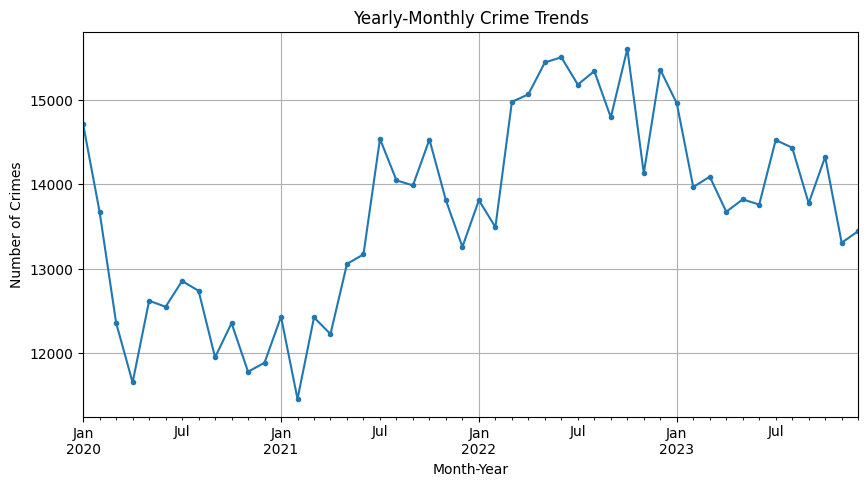

In [ ]:
df1['YearMonth'] = df1['DATE OCC'].dt.to_period('M')

monthly_crimes = df1.groupby('YearMonth').size().sort_index()

plt.figure(figsize=(10, 5))
monthly_crimes.plot(kind='line', marker='.', linestyle='-')
plt.title('Yearly-Monthly Crime Trends')
plt.xlabel('Month-Year')
plt.ylabel('Number of Crimes')

plt.grid(True)
plt.show()

Observation:
- Crimes appear to increase from 2020 to 2023, with highest number of cases in 2022.
- Additionally, crimes tend to rise from Apr-May, Sep-Oct.
- In 2020, there is a significant drop from Jan-Apr probably due to Covid-19? The trend is stable until Feb 2021 because of the lockdown?

#### Weekly trends

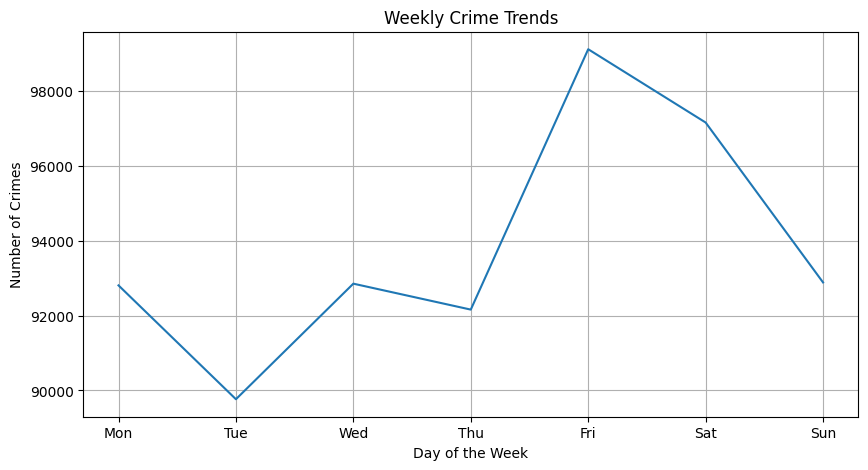

In [ ]:
df1['DayOfWeek'] = df1['DATE OCC'].dt.dayofweek
weekly_crimes = df1['DayOfWeek'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
weekly_crimes.plot(kind='line')
plt.title('Weekly Crime Trends')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Crimes')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
            rotation='horizontal')
plt.grid(True)
plt.show()

Observation:
- This plot shows a peak on Friday, it means that overall, more crimes are reported on Fridays compared to other days of the week.

<Figure size 2000x800 with 0 Axes>

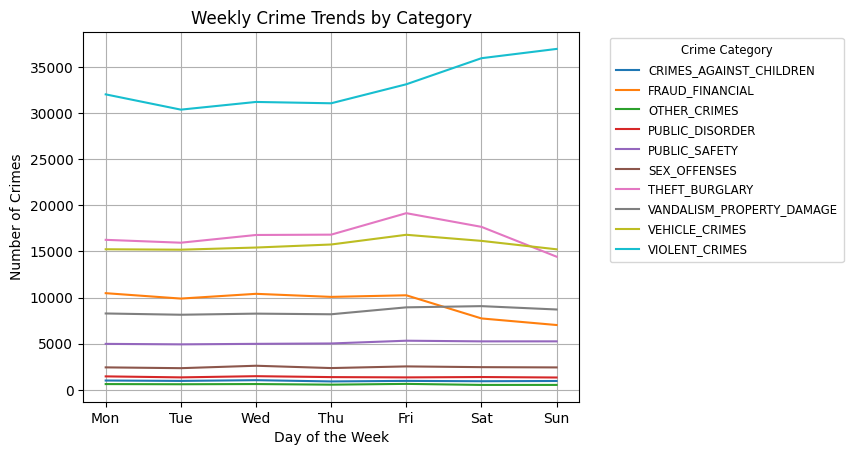

In [ ]:
# weekly trends by crime category
weekly_crime_type = df1.groupby(['DayOfWeek', 'Crime Category']).size().unstack()

plt.figure(figsize=(20, 8))
weekly_crime_type.plot(kind='line')
plt.title('Weekly Crime Trends by Category')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Crimes')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
           rotation='horizontal')
plt.grid(True)
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1),
           fontsize='small', frameon=True, title_fontsize='small',
           borderpad=0.5, labelspacing=0.6)
plt.show()

Observation:
- High-volume categories (like Violent, Theft or Vehicle Crimes) will have lines far higher up the plot than low-volume categories (public disorder, crimes against children...). The patterns of the low-volume crimes might be hard to see because they look like flat lines near the bottom compared to the large fluctuations of the major categories.

#### Hourly trends

<Figure size 1800x800 with 0 Axes>

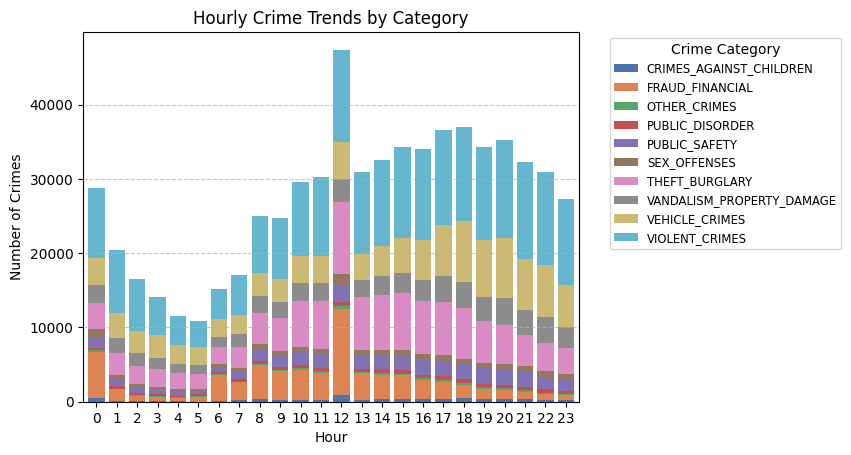

In [ ]:
df1['HourOCC'] = df1['TIME OCC'].astype(str).str.zfill(4).str[:2].astype(int)

hourly_category = df1.groupby(['HourOCC', 'Crime Category']).size().unstack()

plt.figure(figsize=(18, 8))
ax = hourly_category.plot(kind='bar',
                          stacked=True,
                          color=sns.color_palette('deep'),
                          width=0.8)
plt.title('Hourly Crime Trends by Category')
plt.xlabel('Hour')
plt.ylabel('Number of Crimes')
plt.xticks(range(0, 24), rotation='horizontal')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.show()

Observation:
- Crime volumes tend to increase from noon to nighttime especially violent, theft, vehicle crimes.
- Fraud and financial crimes usually occur during lunch break, peak at 12p.m

### Seasonal Spikes by Crime Type

In [ ]:
df1.sample(5).T

,108700,481106,538525,390289,514719
DR_NO,201710627,220111550,220112794,210814227,221811088
Date Rptd,06/29/2020 12:00:00 AM,05/03/2022 12:00:00 AM,05/21/2022 12:00:00 AM,09/20/2021 12:00:00 AM,05/20/2022 12:00:00 AM
DATE OCC,2020-06-25 12:00:00,2022-04-27 12:00:00,2022-05-02 12:00:00,2021-09-19 12:00:00,2022-05-20 12:00:00
TIME OCC,440,30,1610,1300,30
AREA,17,1,1,8,18
AREA NAME,Devonshire,Central,Central,West LA,Southeast
Rpt Dist No,1793,145,161,811,1804
Part 1-2,1,1,1,1,2
Crm Cd,331,330,442,330,930
Crm Cd Desc,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,BURGLARY FROM VEHICLE,SHOPLIFTING - PETTY THEFT ($950 & UNDER),BURGLARY FROM VEHICLE,CRIMINAL THREATS - NO WEAPON DISPLAYED


In [ ]:
top_crimes = df1['Crime Category'].value_counts().head(5).index
top_crimes

Index(['VIOLENT_CRIMES', 'THEFT_BURGLARY', 'VEHICLE_CRIMES', 'FRAUD_FINANCIAL',
       'VANDALISM_PROPERTY_DAMAGE'],
      dtype='object', name='Crime Category')

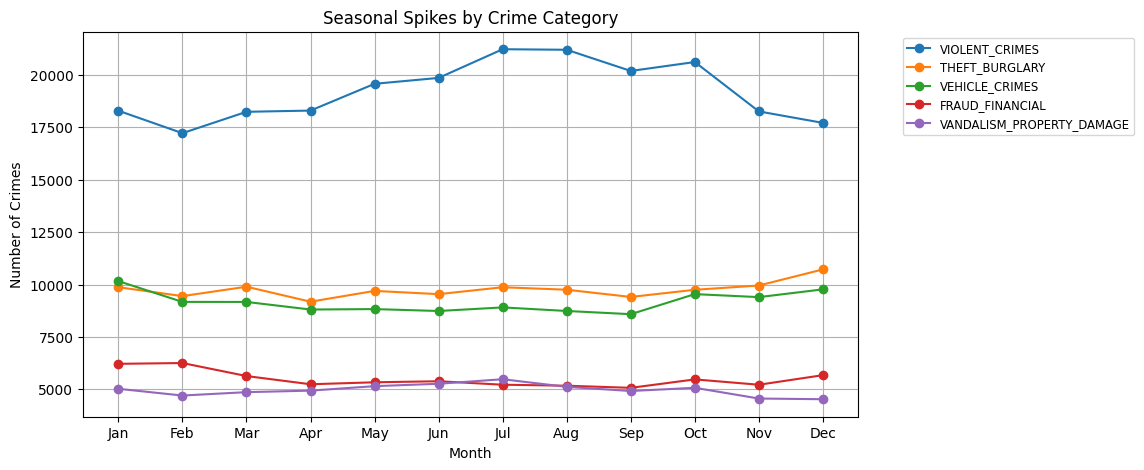

In [ ]:
df1['Month'] = df1['DATE OCC'].dt.month
plt.figure(figsize=(10, 5))
for crime in top_crimes:
    # counting occurrences within groups using .size()
    monthly_data = df1[df1['Crime Category'] == crime].groupby('Month').size()
    monthly_data.plot(kind="line", label=crime, marker='o')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize='small')
plt.title('Seasonal Spikes by Crime Category')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul',
                          'Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.show()

Observation:
- Violent crimes increase during the period of Jun-Oct and decrease till the end of year.
- Other crime types increase slightly around yearend (Nov-Dec).

## 2.2 Geospatial Hotspots

<img src='https://raw.githubusercontent.com/ava-ly/ds-projects/main/crime-in-LA/neighborhood-map-los-angeles.jpg' width=600>

Note:
- Visualizing the individual million points is often unnecessary and inefficient for understanding hotspots. The goal is to see areas of high density or concentration.

<Figure size 1000x500 with 0 Axes>

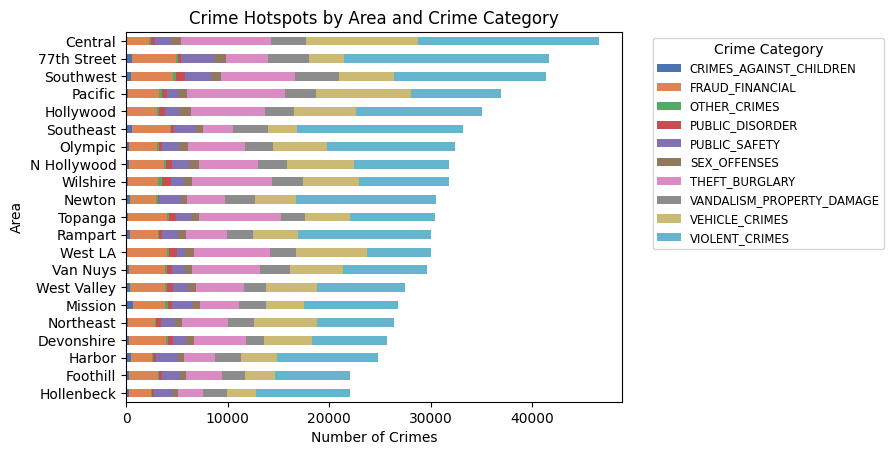

In [ ]:
crime_hotspots = df1.groupby(['AREA NAME', 'Crime Category']).size().unstack()
crime_hotspots['Total'] = crime_hotspots.sum(axis=1)
crime_hotspots = crime_hotspots.sort_values(by='Total', ascending=True) \
                            .drop(columns='Total')

plt.figure(figsize=(10, 5))
crime_hotspots.plot(kind='barh', stacked=True, color=sns.color_palette('deep'))
plt.title('Crime Hotspots by Area and Crime Category')
plt.xlabel('Number of Crimes')
plt.ylabel('Area')
plt.xticks(rotation='horizontal')
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.show()

<Figure size 1000x500 with 0 Axes>

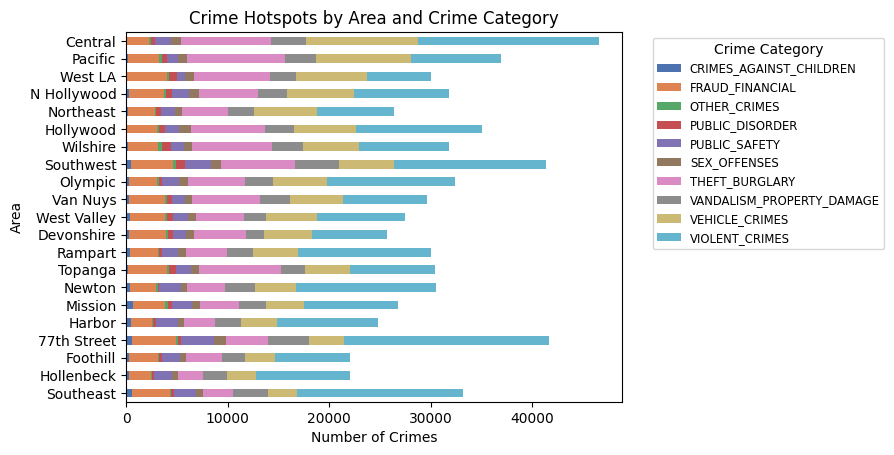

In [ ]:
# sort by vehicle crimes
crime_hotspots = df1.groupby(['AREA NAME', 'Crime Category']).size().unstack() \
                            .sort_values(by='VEHICLE_CRIMES')

plt.figure(figsize=(10, 5))
crime_hotspots.plot(kind='barh', stacked=True, color=sns.color_palette('deep'))
plt.title('Crime Hotspots by Area and Crime Category')
plt.xlabel('Number of Crimes')
plt.ylabel('Area')
plt.xticks(rotation='horizontal')
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.show()

### Observation:
- Overall, the `central` area has the highest number of crimes, followed by 77th Street and Southwest.
- The chart also hightlight top 5 areas of violent crimes: 77th Street, Central, Southeast, Southwest and Newton.
- Whereas theft and vehicle crimes are more likely to happen in Pacific, West LA, Central neighborhood.

### Questions:
*Source: internet, LLMs(Gemini, Deepseek)*

`1. Why Crimes Might Be More Concentrated in "Central Areas" in LA?`
- High Concentration of People: Central areas have vastly higher daytime populations (commuters, workers, visitors) and often significant residential density. More people simply means more potential interactions, leading to more potential victims and offenders in one place.
- Economic Hubs: Downtown is the primary business, financial, and government center.
- Nightlife & Entertainment: These areas often have a high density of bars, clubs, restaurants, and event venues, leading to increased activity (and potential conflict or opportunity) during evening and nighttime hours (assaults, robberies, public order offenses).
- Transit Hubs: Major public transportation hubs (like Union Station, Metro Rail lines) converge in central areas, increasing accessibility for people from all over the region, including potential offenders. It also increases the density of people who might be targets while commuting.
- Mix of Land Use: The dense mix of commercial, residential, entertainment, and sometimes industrial uses creates diverse opportunities for different types of crime at different times of day.
- Tourism: Central locations are often major tourist destinations, and tourists can sometimes be perceived as easier targets for theft or scams.
- Concentrated Disadvantage: Certain central neighborhoods (like Skid Row within Downtown) face extreme concentrations of poverty, homelessness, substance abuse, and mental health issues. This creates a unique and challenging environment with specific crime patterns and high rates of victimization within that community, often related to survival, desperation, or disorder.

`2. Why Theft, Burglary, and Vehicle Crimes Might Be Common in "Pacific" & "West LA" (e.g., Santa Monica, Venice, Westwood, Beverly Hills, Brentwood, Pacific Palisades):`
- Valuable Property: These areas generally have higher property values, more affluent residents, luxury vehicles, and high-end retail stores. This makes them attractive targets for property crimes.
    - Vehicle Crimes: Theft of high-value cars, and theft from vehicles (targeting valuables left inside by residents or visitors, catalytic converters).
    - Burglary: Residential burglaries targeting homes perceived to contain valuables; commercial burglaries targeting boutiques and businesses.
    - Theft: Shoplifting from upscale stores, theft of personal items (phones, wallets, bikes) in public areas, package theft from porches.
- High Volume of Visitors: Places like Santa Monica and Venice attract massive numbers of tourists who may be less attentive to their surroundings or belongings.
- Opportunity: Cars parked near beaches or attractions are targets for break-ins. Beachgoers leaving items unattended are vulnerable to theft. Crowded areas like the Pier or boardwalk can facilitate pickpocketing.
- Residential Patterns: More single-family homes or lower-density apartments might offer easier access points for burglars compared to high-security high-rises.
- Parking: Abundant street parking and parking structures provide ample opportunities for vehicle-related crimes.

`3. Why are violent crimes common in 77th Street area?`
- Poverty and Unemployment: The area historically struggles with higher rates of poverty, unemployment, and underemployment compared to more affluent parts of LA. Lack of economic opportunity can lead to desperation, stress, and conflict, and may make illicit activities seem like a viable alternative for some.
- Limited Educational Opportunities: Disparities in school funding and quality can limit pathways to upward mobility, contributing to cycles of disadvantage.
- Housing Instability: Higher rates of eviction, substandard housing, and density can contribute to stress and instability within the community.
- Presence and Territoriality: South LA, including the 77th Street area, has a long and complex history with street gangs. Much of the violent crime (homicides, shootings, assaults) is often directly linked to gang rivalries, territorial disputes, control of drug markets, and cycles of retaliation.
- Normalization: In some pockets, generations of gang presence can unfortunately lead to a degree of normalization of violence and fewer perceived alternatives for young people.



### Consideration:
- Micro-Locations: Crime is hyper-local. Even within these broad areas, crime rates can vary drastically from one block to the next. A specific busy commercial street might have high theft, while a quiet residential street nearby has very little.
- Reporting Bias: Crime statistics rely on reported incidents. Some areas or communities might be more likely to report certain types of crime than others.
- Policing: Police deployment strategies and enforcement priorities can influence where crime is detected and reported.
- Definitions: The specific definitions of crime categories matter.
- Dynamic Nature: Crime patterns are not static; they change over time due to economic shifts, demographic changes, development, and policing initiatives.

## 2.3 Demographic Analysis

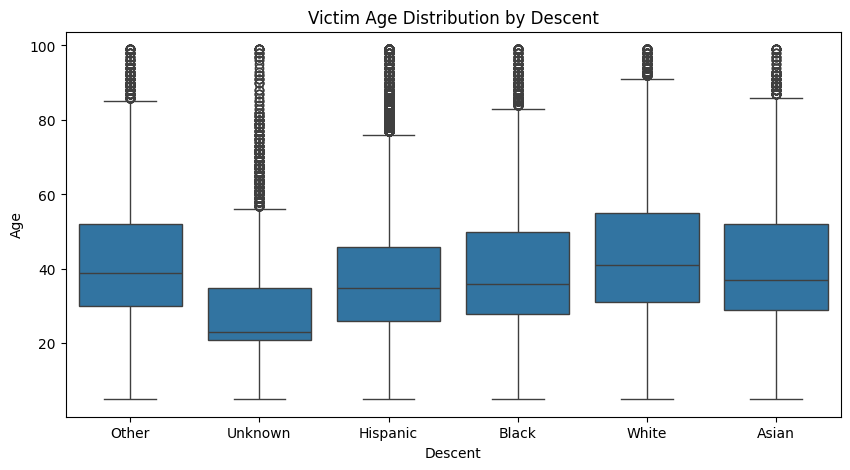

In [ ]:
# Victim age distribution
plt.figure(figsize=(10, 5))
sns.boxplot(data=df1, x='Vict Descent', y='Vict Age')
plt.title('Victim Age Distribution by Descent')
plt.xlabel('Descent')
plt.ylabel('Age')
plt.show()

Observation:
- Victims are commonly adults from around 30-50 years old in all ethnicites. The youngest group is unknown which lacks data to investigate further.

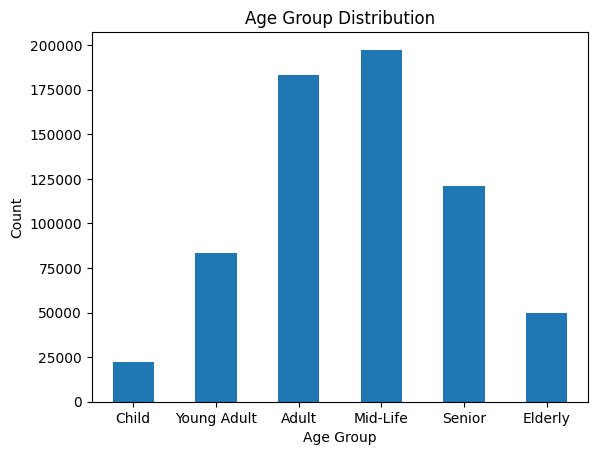

In [ ]:
# Categorize ages
bins = [5, 18, 25, 35, 50, 65, 100]
labels = ['Child','Young Adult','Adult','Mid-Life','Senior','Elderly']
df1['Age Group'] = pd.cut(df1['Vict Age'], bins=bins, labels=labels, right=False)

df1['Age Group'].value_counts().sort_index().plot(kind='bar')
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation='horizontal')
plt.show()

In [ ]:
test_ages = [5, 17, 18, 24, 25, 64, 65, 99]
[pd.cut([age], bins=bins, labels=labels, right=False)[0] for age in test_ages]

['Child',
 'Child',
 'Young Adult',
 'Young Adult',
 'Adult',
 'Senior',
 'Elderly',
 'Elderly']

<Figure size 1000x500 with 0 Axes>

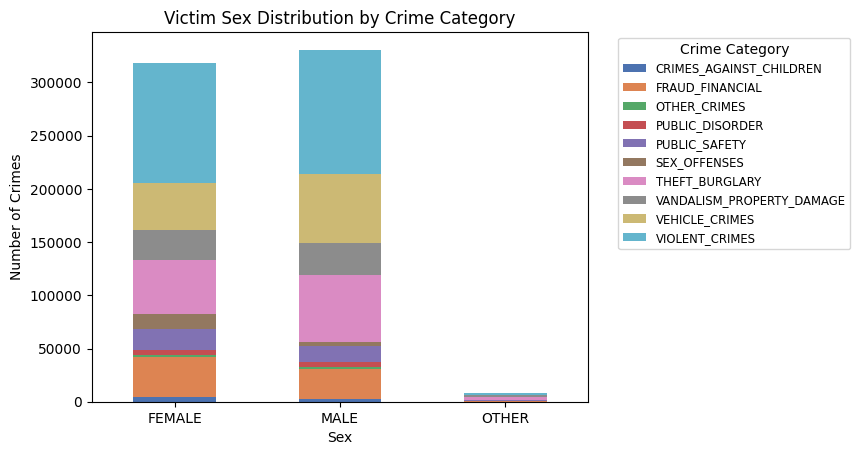

In [ ]:
# Victim sex distribution
sex_counts = df1.groupby(['Vict Sex', 'Crime Category']).size().unstack()

plt.figure(figsize=(10, 5))
sex_counts.plot(kind='bar', stacked=True, color=sns.color_palette('deep'))
plt.title('Victim Sex Distribution by Crime Category')
plt.xlabel('Sex')
plt.ylabel('Number of Crimes')
plt.xticks(rotation='horizontal')
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.show()

Observation:
- Males are commonly being victims of theft, burglary and vehicle crimes than female.
- Females are more likely to be scammed through fraud and financial crimes than male.

## 2.4 Weapon usage

In [ ]:
# weapon usage (top 10) by crime type (top 15)
top_crimes = df1['Crm Cd Desc'].value_counts().nlargest(15).index
top_weapons = df1['Weapon Desc'].value_counts().nlargest(10).index

top_weapons

Index(['Unknown', 'STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)',
       'UNKNOWN WEAPON/OTHER WEAPON', 'VERBAL THREAT', 'HAND GUN',
       'KNIFE WITH BLADE 6INCHES OR LESS', 'SEMI-AUTOMATIC PISTOL',
       'OTHER KNIFE', 'UNKNOWN FIREARM', 'MACE/PEPPER SPRAY'],
      dtype='object', name='Weapon Desc')

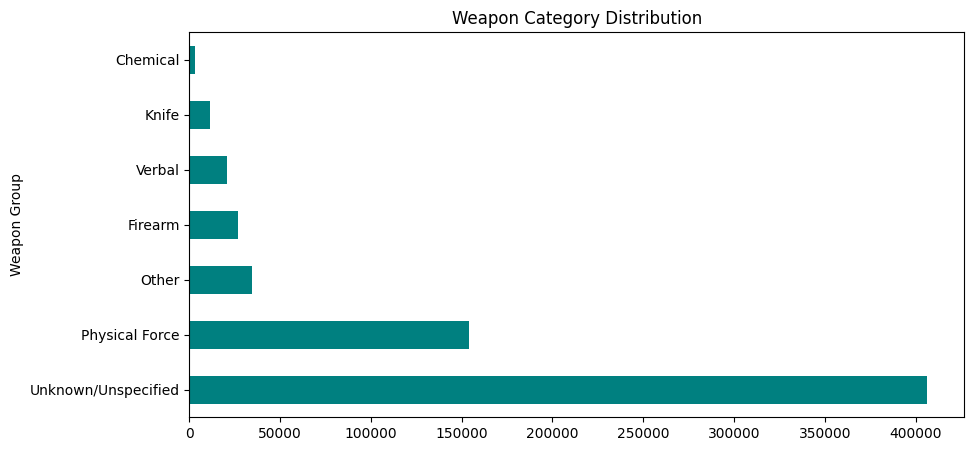

In [ ]:
# Create meaningful weapon groups
weapon_mapping = {
    'Firearm': ['HAND GUN', 'SEMI-AUTOMATIC PISTOL', 'UNKNOWN FIREARM'],
    'Knife': ['KNIFE WITH BLADE 6INCHES OR LESS', 'OTHER KNIFE'],
    'Physical Force': ['STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)'],
    'Chemical': ['MACE/PEPPER SPRAY'],
    'Verbal': ['VERBAL THREAT'],
    'Unknown/Unspecified': ['Unknown', 'UNKNOWN WEAPON/OTHER WEAPON']
}

# Create new weapon category
df1['Weapon Group'] = df1['Weapon Desc'].map(
    lambda x: next((k for k,v in weapon_mapping.items() if x in v), 'Other')
)

# Check distribution
plt.figure(figsize=(10, 5))
df1['Weapon Group'].value_counts().plot(kind='barh', color='teal')
plt.title('Weapon Category Distribution')
plt.show()

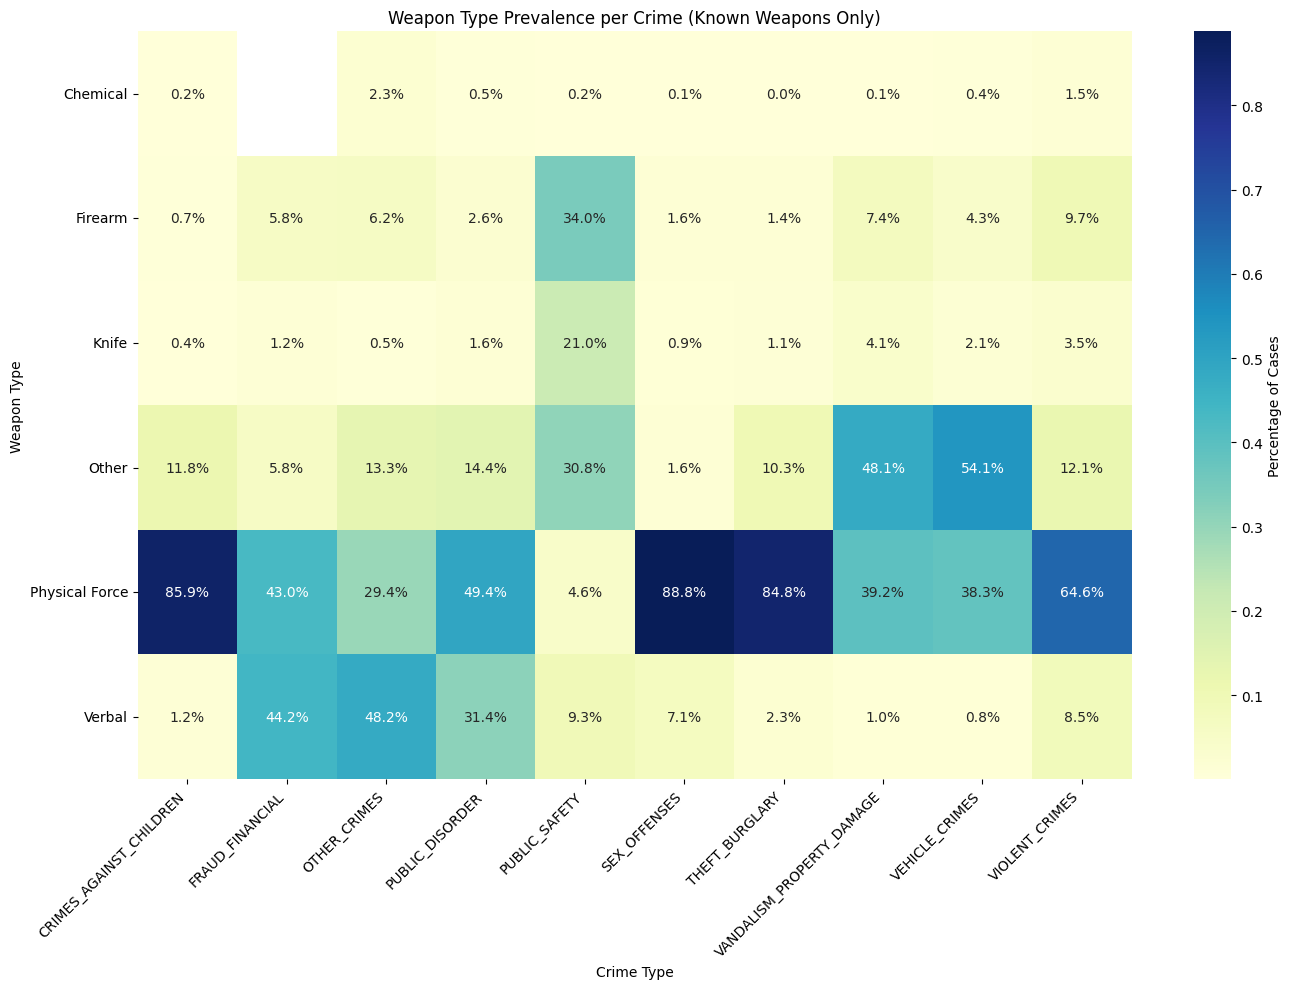

In [ ]:
# Filter out Unknown-dominated crimes
weapon_counts = df1[df1['Weapon Group'] != 'Unknown/Unspecified']\
    .groupby(['Crime Category', 'Weapon Group']).size().unstack()

# Calculate percentages
normalized_counts = weapon_counts.div(weapon_counts.sum(axis=1), axis=0)

plt.figure(figsize=(14, 10))
sns.heatmap(normalized_counts.T, annot=True, fmt='.1%', cmap='YlGnBu',
           cbar_kws={'label': 'Percentage of Cases'})
plt.title('Weapon Type Prevalence per Crime (Known Weapons Only)')
plt.ylabel('Weapon Type')
plt.xlabel('Crime Type')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation='horizontal')
plt.tight_layout()

Observation:
- Physical force is common in all types of crimes (except public safety).
- Knife and firearm is more likely to involve in high-risk crimes which threaten the public safety. Reasonable.

# 3. Feature Engineering

1. Goal: Predict Crime Type (`Crime Category`) based on time, location, victim info, weapon, etc.
2. Target Variable: `Crime Category` (This is a categorical variable, likely with many unique values, making it a multi-class classification problem).
3. Models: Random Forest



In [ ]:
df2 = df.copy()
df2.sample(5).T

,66559,10120,806691,336021,813245
DR_NO,200411467,200316459,230909617,211306884,232008681
Date Rptd,08/05/2020 12:00:00 AM,08/29/2020 12:00:00 AM,05/20/2023 12:00:00 AM,03/06/2021 12:00:00 AM,04/24/2023 12:00:00 AM
DATE OCC,2020-07-29 12:00:00,2020-08-28 12:00:00,2023-04-05 12:00:00,2021-03-06 12:00:00,2023-04-24 12:00:00
TIME OCC,1800,2100,2207,30,130
AREA,4,3,9,13,20
AREA NAME,Hollenbeck,Southwest,Van Nuys,Newton,Olympic
Rpt Dist No,477,357,904,1309,2027
Part 1-2,1,1,1,1,2
Crm Cd,331,761,442,350,626
Crm Cd Desc,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,BRANDISH WEAPON,SHOPLIFTING - PETTY THEFT ($950 & UNDER),"THEFT, PERSON",INTIMATE PARTNER - SIMPLE ASSAULT


In [ ]:
df2 = df2.drop(columns=[
    'DR_NO', 'Date Rptd', 'AREA', 'Rpt Dist No', 'Premis Desc',
    'Status', 'Status Desc', 'LOCATION', 'Crm Cd Desc', 'Crm Cd'])
print(df2.shape)
df2.sample(5)

(656746, 11)


,DATE OCC,TIME OCC,AREA NAME,Part 1-2,Vict Age,Vict Sex,Vict Descent,Weapon Desc,LAT,LON,Crime Category
655700,2023-05-15 12:00:00,1830,Southwest,1,35,MALE,Black,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",34.0148,-118.3222,VIOLENT_CRIMES
611844,2022-03-16 12:00:00,400,Southwest,1,37,FEMALE,Black,Unknown,34.0215,-118.3452,VEHICLE_CRIMES
395720,2021-12-04 12:00:00,800,77th Street,2,35,FEMALE,Black,Unknown,33.9757,-118.3294,FRAUD_FINANCIAL
404312,2021-09-22 12:00:00,1330,Topanga,2,29,MALE,Other,Unknown,34.1761,-118.6167,VANDALISM_PROPERTY_DAMAGE
750105,2023-02-28 12:00:00,500,Foothill,2,27,FEMALE,Hispanic,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",34.2400,-118.3944,VIOLENT_CRIMES


In [ ]:
df2.isna().sum()

,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Part 1-2,0
Vict Age,0
Vict Sex,0
Vict Descent,0
Weapon Desc,0
LAT,0
LON,0


In [ ]:
df2.isna().mean()

,0
DATE OCC,0.0
TIME OCC,0.0
AREA NAME,0.0
Part 1-2,0.0
Vict Age,0.0
Vict Sex,0.0
Vict Descent,0.0
Weapon Desc,0.0
LAT,0.0
LON,0.0


In [ ]:
df2['DATE OCC'] = pd.to_datetime(df2['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p')
df2['day_of_week_occ'] = df2['DATE OCC'].dt.day_of_week
df2 = df2.drop(columns=['DATE OCC'])
df2.head()

,TIME OCC,AREA NAME,Part 1-2,Vict Age,Vict Sex,Vict Descent,Weapon Desc,LAT,LON,Crime Category,day_of_week_occ
1,1800,Central,1,47,MALE,Other,Unknown,34.0444,-118.2628,VEHICLE_CRIMES,5
2,1700,Southwest,1,19,OTHER,Unknown,Unknown,34.0210,-118.3002,VEHICLE_CRIMES,2
3,2037,Van Nuys,1,19,MALE,Other,Unknown,34.1576,-118.4387,THEFT_BURGLARY,1
4,1200,Hollywood,2,28,MALE,Hispanic,Unknown,34.0944,-118.3277,FRAUD_FINANCIAL,0
5,2300,Southeast,2,41,MALE,Hispanic,Unknown,33.9467,-118.2463,FRAUD_FINANCIAL,1


In [ ]:
df2['TIME OCC'] = df2['TIME OCC'].apply(lambda x: int(str(x)[:2]))
df2['TIME OCC']

,TIME OCC
1,18
2,17
3,20
4,12
5,23
...,...
876558,10
876559,22
876560,1
876561,90


In [ ]:
df2 = df2.copy()

columns = ['Vict Sex', 'Vict Descent', 'Weapon Desc', 'AREA NAME']
for column in columns:
    df2 = df2.join(pd.get_dummies(df2[column], prefix=column).astype(int))

df2 = df2.drop(columns=columns)

df2.head()

,TIME OCC,Part 1-2,Vict Age,LAT,LON,Crime Category,day_of_week_occ,Vict Sex_FEMALE,Vict Sex_MALE,Vict Sex_OTHER,...,AREA NAME_Olympic,AREA NAME_Pacific,AREA NAME_Rampart,AREA NAME_Southeast,AREA NAME_Southwest,AREA NAME_Topanga,AREA NAME_Van Nuys,AREA NAME_West LA,AREA NAME_West Valley,AREA NAME_Wilshire
1,18,1,47,34.0444,-118.2628,VEHICLE_CRIMES,5,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,17,1,19,34.0210,-118.3002,VEHICLE_CRIMES,2,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3,20,1,19,34.1576,-118.4387,THEFT_BURGLARY,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,12,2,28,34.0944,-118.3277,FRAUD_FINANCIAL,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,23,2,41,33.9467,-118.2463,FRAUD_FINANCIAL,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0


# 4. Machine Learning Model using Random Forest

## 4.1 Modeling

In [ ]:
target = 'Crime Category'
df2 = df2.sample(10000)
X = df2.drop(columns=[target])
y = df2[target]

In [ ]:
X.isna().sum()

,0
TIME OCC,0
Part 1-2,0
Vict Age,0
LAT,0
LON,0
...,...
AREA NAME_Topanga,0
AREA NAME_Van Nuys,0
AREA NAME_West LA,0
AREA NAME_West Valley,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train

,TIME OCC,Part 1-2,Vict Age,LAT,LON,day_of_week_occ,Vict Sex_FEMALE,Vict Sex_MALE,Vict Sex_OTHER,Vict Descent_Asian,...,AREA NAME_Olympic,AREA NAME_Pacific,AREA NAME_Rampart,AREA NAME_Southeast,AREA NAME_Southwest,AREA NAME_Topanga,AREA NAME_Van Nuys,AREA NAME_West LA,AREA NAME_West Valley,AREA NAME_Wilshire
764218,15,1,39,33.9829,-118.3338,6,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
394440,1,1,53,34.0111,-118.3351,5,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
793216,21,2,45,33.9821,-118.4671,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
331556,10,1,76,34.1558,-118.3943,4,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
358539,14,1,32,34.0444,-118.2541,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631990,13,1,33,33.9514,-118.2352,3,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
817864,15,2,31,34.2281,-118.4553,4,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
171592,18,1,48,33.7273,-118.3275,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
697168,11,2,61,33.9906,-118.4391,5,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                           precision    recall  f1-score   support

  CRIMES_AGAINST_CHILDREN       0.69      0.33      0.45        27
          FRAUD_FINANCIAL       0.47      0.70      0.56       182
             OTHER_CRIMES       0.00      0.00      0.00         7
          PUBLIC_DISORDER       0.00      0.00      0.00        24
            PUBLIC_SAFETY       0.26      0.07      0.12       108
             SEX_OFFENSES       0.46      0.12      0.20        48
           THEFT_BURGLARY       0.61      0.53      0.57       378
VANDALISM_PROPERTY_DAMAGE       0.40      0.37      0.38       187
           VEHICLE_CRIMES       0.59      0.61      0.60       342
           VIOLENT_CRIMES       0.84      0.97      0.90       697

                 accuracy                           0.65      2000
                macro avg       0.43      0.37      0.38      2000
             weighted avg       0.62      0.65      0.63      2000



Observation:
- Best-performing class: VIOLENT_CRIMES (F1 = 0.90). Model detects almost all violent crimes.
- Worst-performing class: OTHER_CRIMES (F1 = 0.00). Model fails to classify these cases.
- Low recall for minor crimes: PUBLIC_SAFETY, SEX_OFFENSES… Model struggles with rare classes.
- Overall Accuracy: 65%
- Macro Avg (0.36 F1): Poor performance on minority classes drags down the average.
- Weighted Avg (0.62 F1): Better due to higher weight on majority classes (e.g., VIOLENT_CRIMES).


## 4.2 Feature importance

In [ ]:
df_feat = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

top_10_features = df_feat.sort_values('importance', ascending=False).head(10)
top_10_features

,feature,importance
92,Weapon Desc_Unknown,0.172418
1,Part 1-2,0.118830
2,Vict Age,0.099404
4,LON,0.096101
3,LAT,0.095855
0,TIME OCC,0.088762
80,"Weapon Desc_STRONG-ARM (HANDS, FIST, FEET OR B...",0.070061
5,day_of_week_occ,0.059353
11,Vict Descent_Hispanic,0.010840
6,Vict Sex_FEMALE,0.010515


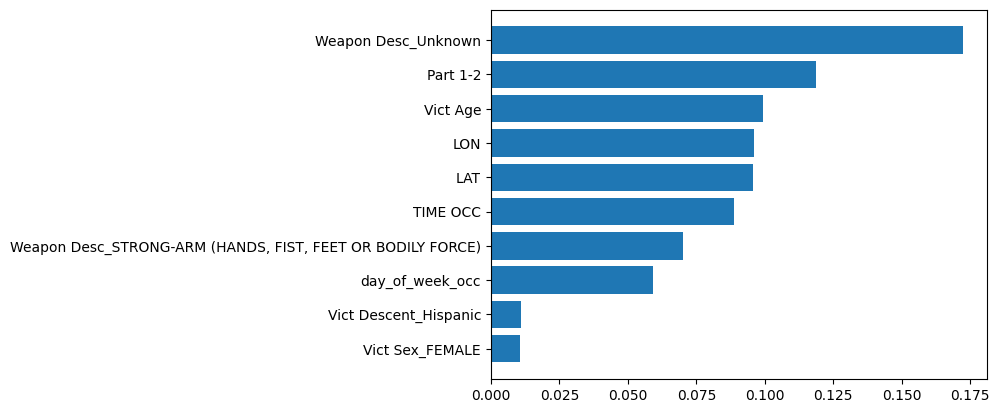

In [ ]:
plt.barh(
    top_10_features["feature"],
    top_10_features["importance"]
)
plt.gca().invert_yaxis()

Observation:
- Weapon description & location (LAT/LON) are highly predictive.
- Part1-2 (serious/less serious), Victim age plays a significant role.
- Time of occurrence (TIME OCC) also contributes to predictions.


## 4.3 SHAP value (SHapley Additive exPlanations)


SHAP aims to explain the prediction of an instance (e.g., predicting the crime category for a specific incident) by computing the contribution of each feature to that specific prediction.

`Why Do We Need to Know SHAP Values?`

- Local Interpretability: SHAP explains individual predictions. Why was this specific incident classified as 'Theft' instead of 'Violent'? Which features pushed the model towards that decision for this case?
- Global Interpretability (Consistent): By aggregating SHAP values (e.g., taking the mean absolute value per feature), you can get a more robust measure of global feature importance that is consistent with the local explanations.
- Feature Interaction & Effect: SHAP summary plots (like the beeswarm plot) show not just if a feature is important, but how its value affects the prediction. Does a high value for HourOfDay increase or decrease the likelihood of predicting 'Burglary'?
- Debugging & Trust: Understand why your model makes certain predictions, identify potential biases (e.g., if a sensitive feature has unexpectedly high SHAP values), and build trust in the model's outputs.
- Model Comparison: Compare how different models rely on different features.

In [ ]:
# import shap

# shap.initjs()

# explainer = shap.TreeExplainer(model)
# shap_values = explainer(X_test)
# shap.summary_plot(shap_values, X_test,
#                   class_names=model.classes_,
#                   plot_size=(12, 6))

<img src='https://raw.githubusercontent.com/ava-ly/ds-projects/main/crime-in-LA/shap_summary_plot.JPG'>

Observation:
- The feature of Victim Age probably affect the decision to identify a incident as crime against children.
- Weapon usage will push the model toward the violent crimes.
- Part 1-2 (serious/less serious) drive the decision to categorize the crime in fraud/financial, vehicle, theft, public safety...

# 5. Report

## 5.1 Key Insights from Data Analysis

1. Crime is Temporally Patterned:
    - Yearly: Covid-19 lockdown probably led to a significant drop of crime incidents from January to April 2020 and lasted until Feb 2021.
    - Monthly/Seasonal: Underlying seasonal trends suggest potential influences of weather, holidays, or school schedules on overall crime volume or specific types.
    - Weekly: Clear weekly rhythms exist, often differing by crime type (e.g., potential increases in violence on weekends, while some property crimes might follow business hours).
    - Hourly: Crime is not uniform throughout the day. Different crime categories peak at different hours (e.g., potential nighttime peaks for violent/vehicle crimes, daytime for fraud/financial). Late night/early morning hours often show distinct patterns.

2. Crime is Geographically Concentrated and correlated with neighborhood characteristics:
    - Crime incidents are not randomly distributed but concentrated in specific geographic areas.
    - Areas with high population density, commercial activity, transit hubs, and entertainment venues (Central LA) tend to be general crime hotspots.
    - Affluent areas with high-value property and vehicles (West LA/Pacific) show concentrations of property and vehicle crimes (opportunity-driven).
    - Areas facing significant socioeconomic disadvantage and historical gang presence (e.g., 77th Street area) show higher concentrations of violent crime (potentially driven by systemic issues and conflict).

3. Specific Crime Types Dominate Volume:
    - After categorization, it's evident that a relatively small number of crime categories (Violent Crimes, Vehicle-Related Crimes, Theft/Burglary) account for a large proportion of the total reported incidents.

4. Victimization Patterns Show Demographic Tendencies:
    - Age Concentration: Adults aged approximately 30-50 represent a common victim demographic across various ethnicities and crime types, suggesting this group experiences significant exposure or vulnerability during their daily activities. The large 'unknown' age group highlights a data gap needing attention for a complete picture.
    - Gendered Victimization: There are clear differences in victimization by gender for certain crimes. Males are more frequently victims of theft, burglary, and vehicle-related crimes, potentially linked to exposure patterns or target suitability. Females are disproportionately targeted for fraud and financial crimes, suggesting different vulnerability vectors or types of interaction exploited by offenders.

5. Weapon Use Varies Significantly by Crime Type:
    - Physical Force is Prevalent: Bodily force is a common element across a wide range of reported crimes (assaults, robberies, even some property crimes during confrontations), indicating a baseline level of physical confrontation risk.
    - Deadly Weapons Tied to High-Risk Crimes: Knives and especially firearms are more strongly associated with higher-severity, high-risk violent crimes and crimes posing a direct threat to public safety (e.g., shots fired, brandishing). This confirms their role in escalating danger.

## 5.2 Recommendations for Enhancing Public Safety

- Dynamic Patrols: Use insights from hourly, weekly patterns to allocate patrol resources dynamically. Increase presence in identified hotspots during the specific time windows when certain crimes are most likely to occur (e.g., focus on vehicle crime hotspots after sunset, nightlife areas on weekend evenings).

- Focus on High-Volume Crimes: Implement specific city-wide or area-specific prevention campaigns targeting the most frequent crime types (e.g., campaigns against leaving valuables in cars, catalytic converter theft prevention, bike registration, shoplifting deterrence partnerships with businesses).

- Collaborate with Communities: Engage residents and businesses within hotspots to understand the specific local drivers of crime and co-develop solutions. Build trust to improve reporting and intelligence gathering.

- Problem-Oriented Policing (POP): Move beyond responding to calls; analyze the underlying conditions contributing to crime in specific hotspots (e.g., poor lighting, abandoned buildings, lack of youth activities) and work with other city agencies and community groups to address them.

- Environmental Design: improving lighting, increasing natural surveillance, controlling access, maintaining properties – to reduce opportunities for crime.

- Support Socioeconomic Development: While a long-term play, insights linking violent crime to disadvantage highlight the need for investment in education, job creation, affordable housing, and youth programs in historically underserved areas like 77th Street area.

- Mental Health & Substance Abuse Services: Increase access to treatment and support services, as these issues often intersect with homelessness, disorder, and sometimes violent crime.


**Overall**: Enhancing public safety requires a multifaceted approach. This data analysis strongly suggests moving beyond reactive responses towards proactive, data-informed strategies that are tailored to specific times, locations, and crime types, while also addressing the underlying socioeconomic and environmental factors that contribute to crime patterns across Los Angeles.